In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score,classification_report, multilabel_confusion_matrix, hamming_loss, accuracy_score

## **Importing Dataset**

In [ ]:
#preprocessing

from google.colab import files

uploaded=files.upload()
path=list(uploaded.keys())[0]


Saving fabsa_dataset.csv to fabsa_dataset.csv


In [ ]:
import pandas as pd

#read csv file
df=pd.read_csv(path)

df.head()

,id,text,labels,org_index,industry,data_source
0,301988849,Literally only place I get my shoes,['company-brand.general-satisfaction.1'],727,Fashion,Google Play
1,301988545,Will not let me login,['account-management.account-access.-1'],727,Fashion,Google Play
2,576785371,"I've already reviewed it, so please let me sig...",['account-management.account-access.0'],5827,Consulting,Apple Store
3,301983983,Easy to use and price is good,"['purchase-booking-experience.ease-of-use.1', ...",549,Travel Booking,Google Play
4,301988330,I find this app easy to use and with an extens...,"['purchase-booking-experience.ease-of-use.1', ...",727,Fashion,Google Play


In [ ]:
print(df.columns)

Index(['id', 'text', 'labels', 'org_index', 'industry', 'data_source'], dtype='object')


## **Machine Learning Models (Logistic Regression, SVM)**

### **ML Preprocessing**

In [ ]:
#text cleaning
!pip install contractions
import re
import string
import contractions

def clean_text_ml(text):

  text=re.sub(r"\s+", " ",text).strip() #remove extra spaces
  text=text.replace('&', 'and') #replace & with and
  text=re.sub(r'#','',text) # replace hashtag with empty
  text=re.sub(r'\W+',' ', text) #remove non-word characters
  text=contractions.fix(text)#expand contractions
  text=text.translate(str.maketrans('','',string.punctuation)) #remove punctuation
  text=re.sub(r"https?://\S+",'',text) #removing url
  text=re.sub(r'<[^>]+>','',text)#removing html
  text=text.lower() #make everything into lowercase

  return text


df['clean_review_ml']=df['text'].apply(clean_text_ml) #clean the text reviews for ml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.2 MB/s eta 0:00:00


In [ ]:
#tokenization

import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

df['tokenized_ml_text']=df['clean_review_ml'].apply(word_tokenize)



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
#removing stop words
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words=set(stopwords.words('english'))

stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('nor')

def remove_stop_words(doc):
  return [word for word in doc if word not in stop_words]

df['removed_stopwords']=df['tokenized_ml_text'].apply(remove_stop_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#lemmetization

from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
lemmatizer=WordNetLemmatizer()

def lemmatize_text(doc):
  lemmatized_words=[]

  for word in doc:
    lemmatized_words.append(lemmatizer.lemmatize(word))

  return lemmatized_words

df['lemmatized_ml_reviews']=df['removed_stopwords'].apply(lambda x: " ".join([lemmatizer.lemmatize(word) for word in x]))

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
#fixing the aspects with their sentiments
import ast

df['labels']=df['labels'].apply(lambda x: ast.literal_eval(x) if isinstance(x,str) else x) #convert from string to list

aspects=[
    'account-management.account-access',
    'company-brand.general-satisfaction',
    'company-brand.competitor',
    'company-brand.reviews',
    'logistics-rides.speed',
    'online-experience.app-website',
    'purchase-booking-experience.ease-of-use',
    'staff-support.attitude-of-staff',
    'staff-support.phone',
    'staff-support.email',
    'value.price-value-for-money',
    'value.discounts-promotion'
]

sentiments=[-1,0,1]

total_labels=[]

for aspect in aspects:
  for sent in sentiments:
    total_labels.append(f"{aspect}.{sent}")



In [ ]:
#splitting training and testing data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

mlb=MultiLabelBinarizer(classes=total_labels)

X=df['lemmatized_ml_reviews']
y=mlb.fit_transform(df['labels'])


X_train_ml, X_test_ml, y_train_ml, y_test_ml=train_test_split(
    X, y, test_size=0.2, random_state=42
)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['value.discounts-promotions.-1', 'value.discounts-promotions.0', 'value.discounts-promotions.1'] will be ignored
  warnings.warn(


In [ ]:
#using tf-idf for ml models

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer=TfidfVectorizer()

X_train_tfidf_ml=vectorizer.fit_transform(X_train_ml)
X_test_tfidf_ml=vectorizer.transform(X_test_ml)


In [ ]:
#BoW vectorizer
bow_vectorizer=CountVectorizer(max_features=20000)

X_train_bow_ml=bow_vectorizer.fit_transform(X_train_ml)
X_test_bow_ml=bow_vectorizer.transform(X_test_ml)

In [ ]:
#Train
lr_bow=OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs'),n_jobs=-1

)
lr_bow.fit(X_train_bow_ml, y_train_ml)


OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000), n_jobs=-1)

In [ ]:
#predict & evaluate

#Model 1: Logistic Regression + BoW
y_pred_lr_bow=lr_bow.predict(X_test_bow_ml)

print("="*55)
print("Model 1: Logistic Regression + BoW")
print("="*55)
p=precision_score(y_test_ml, y_pred_lr_bow, average='micro', zero_division=0)
r=recall_score(y_test_ml, y_pred_lr_bow, average='micro',  zero_division=0)
f1= f1_score(y_test_ml, y_pred_lr_bow, average='micro',  zero_division=0)

print(f"Precision   : {p:.3f}")
print(f"Recall      : {r:.3f}")
print(f"F1 Score    : {f1:.3f}")


Model 1: Logistic Regression + BoW
Precision   : 0.755
Recall      : 0.574
F1 Score    : 0.652


In [ ]:
#Model 2: Logistic Regression with TF-IDF

lr_tfidf=OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs'), n_jobs=-1

)
lr_tfidf.fit(X_train_tfidf_ml, y_train_ml)
y_pred_lr_tfidf=lr_tfidf.predict(X_test_tfidf_ml)

print("="*55)
print("Model 1: Logistic Regression + TF-IDF")
print("="*55)
p=precision_score(y_test_ml, y_pred_lr_tfidf, average='micro', zero_division=0)
r=recall_score(y_test_ml, y_pred_lr_tfidf, average='micro',  zero_division=0)
f1= f1_score(y_test_ml, y_pred_lr_tfidf, average='micro',  zero_division=0)

print(f"Precision   : {p:.3f}")
print(f"Recall      : {r:.3f}")
print(f"F1 Score    : {f1:.3f}")


Model 1: Logistic Regression + TF-IDF
Precision   : 0.844
Recall      : 0.432
F1 Score    : 0.572


In [ ]:
## Model 3: SVM with Bag of words
from sklearn.svm import LinearSVC

svm_bow= OneVsRestClassifier(
    LinearSVC(max_iter=2000, C=1.0),
    n_jobs=-1

)
svm_bow.fit(X_train_bow_ml, y_train_ml)

y_pred_svm_bow=svm_bow.predict(X_test_bow_ml)
print("="*55)
print("Model 1: SVM + Bag of Words")
print("="*55)
p=precision_score(y_test_ml, y_pred_svm_bow, average='micro', zero_division=0)
r=recall_score(y_test_ml, y_pred_svm_bow, average='micro',  zero_division=0)
f1= f1_score(y_test_ml, y_pred_svm_bow, average='micro',  zero_division=0)

print(f"Precision   : {p:.3f}")
print(f"Recall      : {r:.3f}")
print(f"F1 Score    : {f1:.3f}")

Model 1: SVM + Bag of Words
Precision   : 0.691
Recall      : 0.626
F1 Score    : 0.657


In [ ]:
#Model 4: SVM with TF-IDF
svm_tfidf= OneVsRestClassifier(
    LinearSVC(max_iter=2000, C=1.0),
    n_jobs=-1
)
svm_tfidf.fit(X_train_tfidf_ml, y_train_ml)

y_pred_svm_tfidf=svm_tfidf.predict(X_test_tfidf_ml)

y_pred_svm_bow=svm_bow.predict(X_test_bow_ml)
print("="*55)
print("Model 1: SVM + TF-IDF")
print("="*55)
p=precision_score(y_test_ml,y_pred_svm_tfidf, average='micro', zero_division=0)
r=recall_score(y_test_ml, y_pred_svm_tfidf, average='micro',  zero_division=0)
f1= f1_score(y_test_ml,y_pred_svm_tfidf, average='micro',  zero_division=0)

print(f"Precision   : {p:.3f}")
print(f"Recall      : {r:.3f}")
print(f"F1 Score    : {f1:.3f}")

Model 1: SVM + TF-IDF
Precision   : 0.770
Recall      : 0.558
F1 Score    : 0.647


In [ ]:
#Summary table

import pandas as pd

summary = pd.DataFrame({
    'Model': [
        'Logistic Regression + Bow (paper reported)',
        'Logistic Regression + Bow',
        'Logistic Regression + TF-IDF',
        'SVM + Bag of Words',
        'SVM + TF-IDF'
    ],
    'Precision': [
        0.793,
        precision_score(y_test_ml, y_pred_lr_bow, average='micro', zero_division=0),
        precision_score(y_test_ml, y_pred_lr_tfidf, average='micro', zero_division=0),
        precision_score(y_test_ml, y_pred_svm_bow, average='micro', zero_division=0),
        precision_score(y_test_ml,y_pred_svm_tfidf, average='micro', zero_division=0)

    ],
    'Recall': [
        0.512,
        recall_score(y_test_ml, y_pred_lr_bow, average='micro',  zero_division=0),
        recall_score(y_test_ml, y_pred_lr_tfidf, average='micro',  zero_division=0),
        recall_score(y_test_ml, y_pred_svm_bow, average='micro',  zero_division=0),
        recall_score(y_test_ml, y_pred_svm_tfidf, average='micro',  zero_division=0)

    ],
    'F1 Score': [
        0.623,
         f1_score(y_test_ml, y_pred_lr_bow, average='micro',  zero_division=0),
         f1_score(y_test_ml, y_pred_lr_tfidf, average='micro',  zero_division=0),
         f1_score(y_test_ml, y_pred_svm_bow, average='micro',  zero_division=0),
         f1_score(y_test_ml,y_pred_svm_tfidf, average='micro',  zero_division=0)





    ]


}).round(3)

print("\n" + "="*55)
print("Results Summary (micro-avg. 80/20 split)")
print("="*55)

print(summary.to_string(index=False))


Results Summary (micro-avg. 80/20 split)
                                     Model  Precision  Recall  F1 Score
Logistic Regression + Bow (paper reported)      0.793   0.512     0.623
                 Logistic Regression + Bow      0.755   0.574     0.652
              Logistic Regression + TF-IDF      0.844   0.432     0.572
                        SVM + Bag of Words      0.691   0.626     0.657
                              SVM + TF-IDF      0.770   0.558     0.647


In [ ]:
# Per-label for Best model

import numpy as np

f1_scores={
    'LogReg-Bow':          f1_score(y_test_ml, y_pred_lr_bow, average='micro',  zero_division=0),
    'LogReg-TFIDF':        f1_score(y_test_ml, y_pred_lr_tfidf, average='micro',  zero_division=0),
    'SVM-Bow':          f1_score(y_test_ml, y_pred_svm_bow, average='micro',  zero_division=0),
    'SVM-TFIDF':          f1_score(y_test_ml,y_pred_svm_tfidf, average='micro',  zero_division=0)
}

best_model_name=max(f1_scores, key=f1_scores.get)
preds_map={
    'LogReg-Bow': y_pred_lr_bow,
    'LogReg-TFIDF': y_pred_lr_tfidf,
    'SVM-Bow': y_pred_svm_bow,
    'SVM-TFIDF': y_pred_svm_tfidf

}
print(f"\nBest Model: {best_model_name} (F1={f1_scores[best_model_name]:.3f})")
print("\nPer-label classification report:")
print(classification_report(
    y_test_ml,
    preds_map[best_model_name],
    target_names=mlb.classes_,
    zero_division=0
    ))



Best Model: SVM-Bow (F1=0.657)

Per-label classification report:
                                            precision    recall  f1-score   support

      account-management.account-access.-1       0.59      0.45      0.51        77
       account-management.account-access.0       0.73      0.77      0.75        39
       account-management.account-access.1       0.00      0.00      0.00        11
     company-brand.general-satisfaction.-1       0.51      0.31      0.38       169
      company-brand.general-satisfaction.0       0.00      0.00      0.00         4
      company-brand.general-satisfaction.1       0.68      0.66      0.67       609
               company-brand.competitor.-1       0.34      0.22      0.27        45
                company-brand.competitor.0       0.00      0.00      0.00         2
                company-brand.competitor.1       0.69      0.67      0.68       115
                  company-brand.reviews.-1       0.56      0.70      0.62        20
         

In [ ]:
#Train
lr_bow=OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs'),n_jobs=-1

)
lr_bow.fit(X_train_bow_ml, y_train_ml)


OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000), n_jobs=-1)

In [ ]:
#predict & evaluate

#Model 1: Logistic Regression + BoW
y_pred_lr_bow=lr_bow.predict(X_test_bow_ml)

print("="*55)
print("Model 1: Logistic Regression + BoW")
print("="*55)
a=accuracy_score(y_test_ml, y_pred_lr_bow)
p=precision_score(y_test_ml, y_pred_lr_bow, average='micro', zero_division=0)
r=recall_score(y_test_ml, y_pred_lr_bow, average='micro',  zero_division=0)
f1= f1_score(y_test_ml, y_pred_lr_bow, average='micro',  zero_division=0)

print(f"Accuracy    : {a:.3f}")
print(f"Precision   : {p:.3f}")
print(f"Recall      : {r:.3f}")
print(f"F1 Score    : {f1:.3f}")


Model 1: Logistic Regression + BoW
Accuracy    : 0.367
Precision   : 0.755
Recall      : 0.574
F1 Score    : 0.652


In [ ]:
#Model 2: Logistic Regression with TF-IDF

lr_tfidf=OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs'), n_jobs=-1

)
lr_tfidf.fit(X_train_tfidf_ml, y_train_ml)
y_pred_lr_tfidf=lr_tfidf.predict(X_test_tfidf_ml)

print("="*55)
print("Model 2: Logistic Regression + TF-IDF")
print("="*55)
a=accuracy_score(y_test_ml, y_pred_lr_tfidf)
p=precision_score(y_test_ml, y_pred_lr_tfidf, average='micro', zero_division=0)
r=recall_score(y_test_ml, y_pred_lr_tfidf, average='micro',  zero_division=0)
f1= f1_score(y_test_ml, y_pred_lr_tfidf, average='micro',  zero_division=0)

print(f"Accuracy    : {a:.3f}")
print(f"Precision   : {p:.3f}")
print(f"Recall      : {r:.3f}")
print(f"F1 Score    : {f1:.3f}")


Model 2: Logistic Regression + TF-IDF
Accuracy    : 0.335
Precision   : 0.844
Recall      : 0.432
F1 Score    : 0.572


In [ ]:
## Model 3: SVM with Bag of words
from sklearn.svm import LinearSVC

svm_bow= OneVsRestClassifier(
    LinearSVC(max_iter=2000, C=1.0),
    n_jobs=-1

)
svm_bow.fit(X_train_bow_ml, y_train_ml)

y_pred_svm_bow=svm_bow.predict(X_test_bow_ml)
print("="*55)
print("Model 3: SVM + Bag of Words")
print("="*55)

a=accuracy_score(y_test_ml, y_pred_svm_bow)
p=precision_score(y_test_ml, y_pred_svm_bow, average='micro', zero_division=0)
r=recall_score(y_test_ml, y_pred_svm_bow, average='micro',  zero_division=0)
f1= f1_score(y_test_ml, y_pred_svm_bow, average='micro',  zero_division=0)

print(f"Accuracy    : {a:.3f}")
print(f"Precision   : {p:.3f}")
print(f"Recall      : {r:.3f}")
print(f"F1 Score    : {f1:.3f}")

Model 3: SVM + Bag of Words
Accuracy    : 0.387
Precision   : 0.691
Recall      : 0.626
F1 Score    : 0.657


In [ ]:
#Model 4: SVM with TF-IDF
svm_tfidf= OneVsRestClassifier(
    LinearSVC(max_iter=2000, C=1.0),
    n_jobs=-1
)
svm_tfidf.fit(X_train_tfidf_ml, y_train_ml)

y_pred_svm_tfidf=svm_tfidf.predict(X_test_tfidf_ml)

y_pred_svm_bow=svm_bow.predict(X_test_bow_ml)
print("="*55)
print("Model 4: SVM + TF-IDF")
print("="*55)

a=accuracy_score(y_test_ml, y_pred_svm_tfidf)
p=precision_score(y_test_ml,y_pred_svm_tfidf, average='micro', zero_division=0)
r=recall_score(y_test_ml, y_pred_svm_tfidf, average='micro',  zero_division=0)
f1= f1_score(y_test_ml,y_pred_svm_tfidf, average='micro',  zero_division=0)

print(f"Accuracy    : {a:.3f}")
print(f"Precision   : {p:.3f}")
print(f"Recall      : {r:.3f}")
print(f"F1 Score    : {f1:.3f}")

Model 4: SVM + TF-IDF
Accuracy    : 0.399
Precision   : 0.770
Recall      : 0.558
F1 Score    : 0.647


In [ ]:
#Summary table

import pandas as pd

summary = pd.DataFrame({
    'Model': [
        'Logistic Regression + Bow (paper reported)',
        'Logistic Regression + Bow',
        'Logistic Regression + TF-IDF',
        'SVM + Bag of Words',
        'SVM + TF-IDF'
    ],
    'Precision': [
        0.793,
        precision_score(y_test_ml, y_pred_lr_bow, average='micro', zero_division=0),
        precision_score(y_test_ml, y_pred_lr_tfidf, average='micro', zero_division=0),
        precision_score(y_test_ml, y_pred_svm_bow, average='micro', zero_division=0),
        precision_score(y_test_ml,y_pred_svm_tfidf, average='micro', zero_division=0)

    ],
    'Recall': [
        0.512,
        recall_score(y_test_ml, y_pred_lr_bow, average='micro',  zero_division=0),
        recall_score(y_test_ml, y_pred_lr_tfidf, average='micro',  zero_division=0),
        recall_score(y_test_ml, y_pred_svm_bow, average='micro',  zero_division=0),
        recall_score(y_test_ml, y_pred_svm_tfidf, average='micro',  zero_division=0)

    ],
    'F1 Score': [
        0.623,
         f1_score(y_test_ml, y_pred_lr_bow, average='micro',  zero_division=0),
         f1_score(y_test_ml, y_pred_lr_tfidf, average='micro',  zero_division=0),
         f1_score(y_test_ml, y_pred_svm_bow, average='micro',  zero_division=0),
         f1_score(y_test_ml,y_pred_svm_tfidf, average='micro',  zero_division=0)





    ]


}).round(3)

print("\n" + "="*55)
print("Results Summary (micro-avg. 80/20 split)")
print("="*55)

print(summary.to_string(index=False))


Results Summary (micro-avg. 80/20 split)
                                     Model  Precision  Recall  F1 Score
Logistic Regression + Bow (paper reported)      0.793   0.512     0.623
                 Logistic Regression + Bow      0.755   0.574     0.652
              Logistic Regression + TF-IDF      0.844   0.432     0.572
                        SVM + Bag of Words      0.691   0.626     0.657
                              SVM + TF-IDF      0.770   0.558     0.647


In [ ]:
def cal_accuracy(model_name, y_true, y_pred):
  """
  Multi-label equivalent of the cal_accuracy function
  -Aggregated confusion matrix (summed accross all 36 labels)
  -Hamming Accuracy (multi-label equivalent of accuracy)
  -classification report (per label P/ R/ F1)
  """

  print("="*60)
  print(f" {model_name}")
  print("="*60)

  #Aggregated Confusion Matrix

  mcm=multilabel_confusion_matrix(y_true, y_pred)
  cm=mcm.sum(axis=0) #sum accross all 36 labels --> 2x2
  tn, fp,fn, tp=cm[0,0], cm[0,1], cm[1,0], cm[1,1]

  print("\nAggregated Confusion Matrix (summed across all 36 lables): ")
  print(f"              Predicted 0     Predicted 1")
  print(f"  Actual 0        {tn:>7,}        {fp:>7,}  (TN / FP)")
  print(f"  Actual 1        {fn:>7,}        {tp:>7,}  (FN / TP)")



#Accuarcy results (two versions)

#exact accuarcy

  exact_acc=accuracy_score(y_true, y_pred)*100
  print(f"\n Exact-Match Accuarcy : {exact_acc:.2f}%")
  print(f" (sample only counts as correct if all 36 labels match exactly)")
  # Hamming Accuracy
  # Hamming Loss= fraction of labels predicted wrongly per sample
  # Hamming accuracy =1-hamming_loss (multi-label accuracy)

  h_acc= (1- hamming_loss(y_true, y_pred))*100
  print(f"\nHamming Accuracy : {h_acc:.2f}%")
  print(f" (= 1 - Hamming Loss: multi-label equivalent of accuracy)")


  #Micro-avg P/R/ F1
  p=precision_score(y_true, y_pred, average='micro', zero_division=0)
  r= recall_score(y_true, y_pred, average='micro', zero_division=0)
  f1= f1_score(y_true, y_pred, average='micro', zero_division=0)

  #Classification Report
  print("\nClassififcation Report (per label): ")
  print(classification_report(
      y_true, y_pred,
      target_names=mlb.classes_,
      zero_division=0
  ))




In [ ]:
# Per-label for Best model

import numpy as np

f1_scores={
    'LogReg-Bow':          f1_score(y_test_ml, y_pred_lr_bow, average='micro',  zero_division=0),
    'LogReg-TFIDF':        f1_score(y_test_ml, y_pred_lr_tfidf, average='micro',  zero_division=0),
    'SVM-Bow':          f1_score(y_test_ml, y_pred_svm_bow, average='micro',  zero_division=0),
    'SVM-TFIDF':          f1_score(y_test_ml,y_pred_svm_tfidf, average='micro',  zero_division=0)
}

best_model_name=max(f1_scores, key=f1_scores.get)
preds_map={
    'LogReg-Bow': y_pred_lr_bow,
    'LogReg-TFIDF': y_pred_lr_tfidf,
    'SVM-Bow': y_pred_svm_bow,
    'SVM-TFIDF': y_pred_svm_tfidf

}
print(f"\nBest Model: {best_model_name} (F1={f1_scores[best_model_name]:.3f})")
#print("\nPer-label classification report:")
#print(classification_report(
    #y_test_ml,
    #preds_map[best_model_name],
    #target_names=mlb.classes_,
    #zero_division=0
    #))



Best Model: SVM-Bow (F1=0.657)


In [ ]:
cal_accuracy("LogReg-BoW (paper baseline)", y_test_ml, y_pred_lr_bow)
cal_accuracy("LogReg-TF-IDF", y_test_ml, y_pred_lr_tfidf)
cal_accuracy("SVM-BoW" , y_test_ml, y_pred_svm_bow)
cal_accuracy("SVM-TF-IDF", y_test_ml, y_pred_svm_tfidf)

 LogReg-BoW (paper baseline)

Aggregated Confusion Matrix (summed across all 36 lables): 
              Predicted 0     Predicted 1
  Actual 0         71,865            670  (TN / FP)
  Actual 1          1,537          2,068  (FN / TP)

 Exact-Match Accuarcy : 36.69%
 (sample only counts as correct if all 36 labels match exactly)

Hamming Accuracy : 97.10%
 (= 1 - Hamming Loss: multi-label equivalent of accuracy)

Classififcation Report (per label): 
                                            precision    recall  f1-score   support

      account-management.account-access.-1       0.67      0.40      0.50        77
       account-management.account-access.0       0.84      0.67      0.74        39
       account-management.account-access.1       0.00      0.00      0.00        11
     company-brand.general-satisfaction.-1       0.55      0.23      0.33       169
      company-brand.general-satisfaction.0       0.00      0.00      0.00         4
      company-brand.general-satisfaction

# **Deep Learning Models ( RoBERTa & DeBERTa**

In [ ]:
#preprocessing

def clean_text_bert(text):

  text=re.sub(r"\s+", " ",text).strip() #remove extra spaces
  text=text.replace('&', 'and') #replace & with and
  text=re.sub(r'#','',text)# replace hashtag with empty
  text=re.sub(r"https?://\S+",'',text) #removing url
  text=re.sub(r'<[^>]+>','',text)#removing html

  return text

df['clean_bert_reviews']=df['text'].apply(clean_text_bert) #clean the text reviews for bert

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

# Multi-label encoding
mlb = MultiLabelBinarizer()

y = mlb.fit_transform(df['labels'])
y = y.astype(np.float32)

# USE ORIGINAL REVIEW TEXT
X = df['clean_bert_reviews']

# Train/Test Split
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Size:", len(X_train_dl))
print("Test Size:", len(X_test_dl))
print("Number of Labels:", y.shape[1])

Train Size: 8459
Test Size: 2115
Number of Labels: 36


In [ ]:
import pandas as pd
import numpy as np
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
train_df = pd.DataFrame({
    "text": X_train_dl.values,
    "labels": list(y_train_dl.astype(np.float32))
})

test_df = pd.DataFrame({
    "text": X_test_dl.values,
    "labels": list(y_test_dl.astype(np.float32))
})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "roberta-base"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/8459 [00:00<?, ? examples/s]

Map:   0%|          | 0/2115 [00:00<?, ? examples/s]

### **RoBERTa**

In [ ]:
num_labels = y_train_dl.shape[1]

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./roberta_results",

    num_train_epochs=5,

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    weight_decay=0.01
)

In [ ]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

In [ ]:
trainer.train()

Step,Training Loss
500,0.183947
1000,0.109697
1500,0.088720
2000,0.078755
2500,0.067198
3000,0.063567
3500,0.056470
4000,0.052833
4500,0.050287
5000,0.046109


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5290, training_loss=0.07795982649285761, metrics={'train_runtime': 1215.9572, 'train_samples_per_second': 34.783, 'train_steps_per_second': 4.35, 'total_flos': 2782919810626560.0, 'train_loss': 0.07795982649285761, 'epoch': 5.0})

In [ ]:
predictions = trainer.predict(
    test_dataset
)

probs = torch.sigmoid(
    torch.tensor(
        predictions.predictions
    )
)

y_pred_roberta = (
    probs > 0.5
).int().numpy()

In [ ]:
precision = precision_score(
    y_test_dl,
    y_pred_roberta,
    average='micro',
    zero_division=0
)

recall = recall_score(
    y_test_dl,
    y_pred_roberta,
    average='micro',
    zero_division=0
)

f1 = f1_score(
    y_test_dl,
    y_pred_roberta,
    average='micro',
    zero_division=0
)

print("="*50)
print("ROBERTA RESULTS")
print("="*50)

print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

ROBERTA RESULTS
Precision: 0.834
Recall   : 0.7274
F1 Score : 0.7771


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_roberta = accuracy_score(
    y_test_dl,
    y_pred_roberta
)

print("RoBERTa Accuracy:", round(accuracy_roberta,4))

RoBERTa Accuracy: 0.5513


In [ ]:
from sklearn.metrics import hamming_loss

hamming_acc_roberta = 1 - hamming_loss(
    y_test_dl,
    y_pred_roberta
)

print(
    "RoBERTa Hamming Accuracy:",
    round(hamming_acc_roberta,4)
)

RoBERTa Hamming Accuracy: 0.9796


### **DeBERTa**

In [ ]:
MODEL_NAME = "microsoft/deberta-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/8459 [00:00<?, ? examples/s]

Map:   0%|          | 0/2115 [00:00<?, ? examples/s]

In [ ]:
train_dataset = train_dataset.remove_columns(
    ["text"]
)

test_dataset = test_dataset.remove_columns(
    ["text"]
)

In [ ]:
print(train_dataset.column_names)

['labels', 'input_ids', 'attention_mask', 'token_type_ids']


In [ ]:
num_labels = y_train_dl.shape[1]

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

#checking that model is loaded on gpu
model.to(device)
print("Model loaded on:", next(model.parameters()).device)

pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using: cuda
Model loaded on: cuda:0


In [ ]:
training_args = TrainingArguments(
    output_dir="./deberta_results",

    num_train_epochs=10,

    learning_rate=3e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    weight_decay=0.01,

    max_grad_norm=1.0,

    logging_steps=100
)

In [ ]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

In [ ]:
trainer.train()

Step,Training Loss
100,0.272231
200,0.145298
300,0.126097
400,0.107546
500,0.099322
600,0.095989
700,0.087963
800,0.086457
900,0.079742
1000,0.079154


model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=10580, training_loss=0.03389376662178616, metrics={'train_runtime': 3142.0387, 'train_samples_per_second': 26.922, 'train_steps_per_second': 3.367, 'total_flos': 6485471307786240.0, 'train_loss': 0.03389376662178616, 'epoch': 10.0})

In [ ]:
predictions = trainer.predict(
    test_dataset
)

In [ ]:
print(
    "NaN count:",
    np.isnan(predictions.predictions).sum()
)

NaN count: 0


In [ ]:
probs = torch.sigmoid(
    torch.tensor(predictions.predictions)
)

y_pred = (
    probs > 0.5
).int().numpy()

In [ ]:
precision = precision_score(
    y_test_dl,
    y_pred,
    average='micro',
    zero_division=0
)

recall = recall_score(
    y_test_dl,
    y_pred,
    average='micro',
    zero_division=0
)

f1 = f1_score(
    y_test_dl,
    y_pred,
    average='micro',
    zero_division=0
)

print("="*50)
print("DEBERTA RESULTS")
print("="*50)

print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

DEBERTA RESULTS
Precision: 0.8073
Recall   : 0.8017
F1 Score : 0.8045


In [ ]:
#find better threshold
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:

  y_pred_temp=(probs>threshold).int().numpy()

  precision=precision_score(
      y_test_dl, y_pred_temp,
      average='micro', zero_division=0
  )


  recall=recall_score(
      y_test_dl, y_pred_temp,
      average='micro', zero_division=0
  )


  f1=f1_score(
      y_test_dl, y_pred_temp,
      average='micro', zero_division=0
  )

  print(f"Threshold {threshold:.2f}: P={precision:.4f}, R={recall:.4f}, F1={f1:.4f}")

Threshold 0.30: P=0.7783, R=0.8313, F1=0.8039
Threshold 0.35: P=0.7867, R=0.8216, F1=0.8037
Threshold 0.40: P=0.7965, R=0.8162, F1=0.8062
Threshold 0.45: P=0.8007, R=0.8097, F1=0.8052
Threshold 0.50: P=0.8073, R=0.8017, F1=0.8045


In [ ]:
#optimize
probs=torch.sigmoid(torch.tensor(predictions.predictions)).numpy()
num_labels=probs.shape[1]

print("="*70)
print("Threshold OPTIMIZATION- Results")
print("="*70)

optimal_thresholds=[]

threshold_range=np.arange(0.1,0.9,0.05)

for label_idx in range(num_labels):
  label_probs=probs[:,label_idx]
  label_true=y_test_dl[:,label_idx]

  if np.sum(label_true)<3:
    optimal_thresholds.append(0.45)
    continue

  best_f1_label=0
  best_threshold_label=0.45

  for threshold in threshold_range:
    y_pred_label=(label_probs>threshold)
    f1_label=f1_score(label_true, y_pred_label)

    if f1_label > best_f1_label:
      best_f1_label=f1_label
      best_threshold_label=threshold

  optimal_thresholds.append(best_threshold_label)

y_pred_per_label=np.zeros_like(probs)

for label_idx, threshold in enumerate(optimal_thresholds):
  y_pred_per_label[:,label_idx]=(probs[:,label_idx]>threshold).astype(int)



# calculate metrics

precision = precision_score(
    y_test_dl, y_pred_per_label,
    average='micro', zero_division=0
)

recall = recall_score(
    y_test_dl, y_pred_per_label,
    average='micro', zero_division=0
)

f1 = f1_score(
    y_test_dl, y_pred_per_label,
    average='micro', zero_division=0
)

print("Final DEBERTA RESULTS")
print(f"P={precision:.4f}")
print(f"R={recall:.4f}")
print(f"F1={f1:.4f}")

Threshold OPTIMIZATION- Results
Final DEBERTA RESULTS
P=0.7957
R=0.8302
F1=0.8126


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_deberta=accuracy_score(
    y_test_dl, y_pred
)

print("DeBERTa Accuracy:",round(accuracy_deberta,4))

DeBERTa Accuracy: 0.5759


In [ ]:
from sklearn.metrics import hamming_loss

hamming_acc = 1 - hamming_loss(y_test_dl, y_pred)

print("Hamming Accuracy:", round(hamming_acc,4))

Hamming Accuracy: 0.981


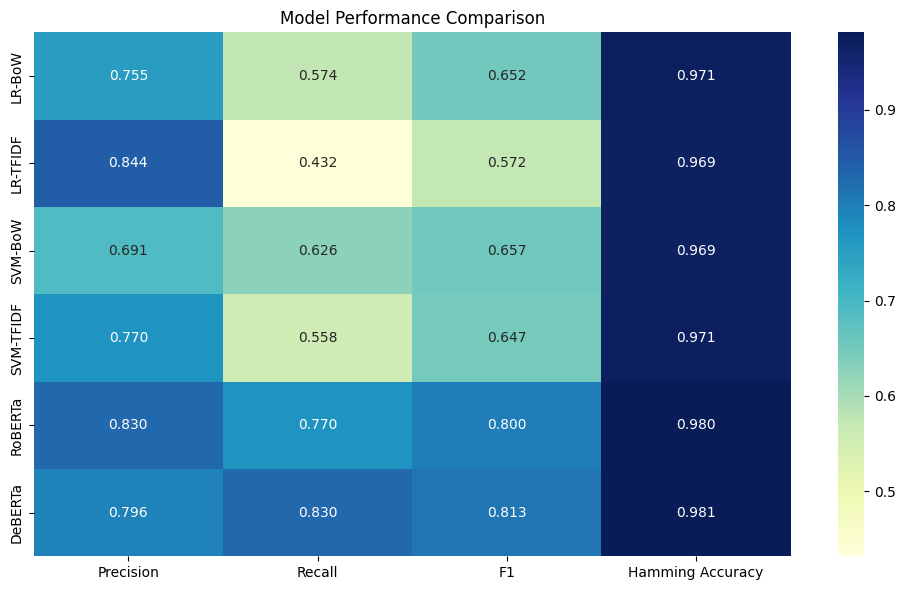

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Precision": [0.755, 0.844, 0.691, 0.770, 0.830, 0.796],
    "Recall":    [0.574, 0.432, 0.626, 0.558, 0.770, 0.830],
    "F1":        [0.652, 0.572, 0.657, 0.647, 0.800, 0.813],
    "Hamming Accuracy":   [0.971, 0.969, 0.969, 0.971, 0.980, 0.981]
},
index=[
    "LR-BoW",
    "LR-TFIDF",
    "SVM-BoW",
    "SVM-TFIDF",
    "RoBERTa",
    "DeBERTa"
])

plt.figure(figsize=(10,6))
sns.heatmap(results,
            annot=True,
            cmap="YlGnBu",
            fmt=".3f")

plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()

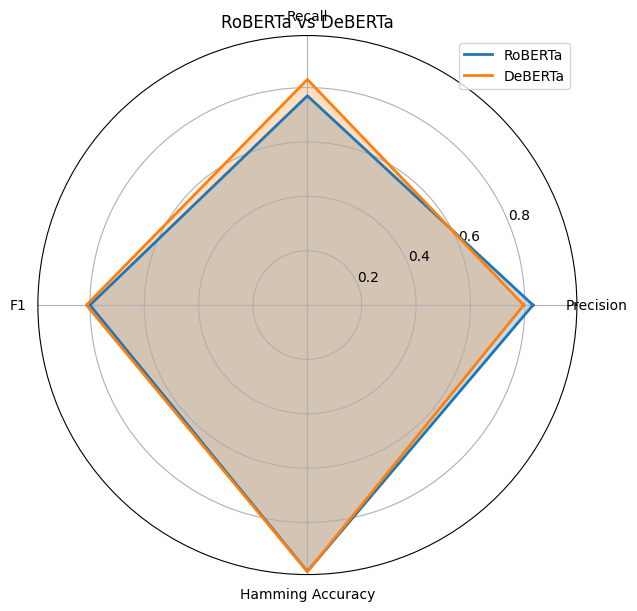

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

categories = [
    "Precision",
    "Recall",
    "F1",
    "Hamming Accuracy"
]

roberta = [0.83, 0.77, 0.80, 0.98]
deberta = [0.796, 0.830, 0.813, 0.981]

N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()

roberta += roberta[:1]
deberta += deberta[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

ax.plot(angles, roberta, linewidth=2, label='RoBERTa')
ax.fill(angles, roberta, alpha=0.25)

ax.plot(angles, deberta, linewidth=2, label='DeBERTa')
ax.fill(angles, deberta, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.title("RoBERTa vs DeBERTa")
plt.legend(loc="upper right")
plt.show()

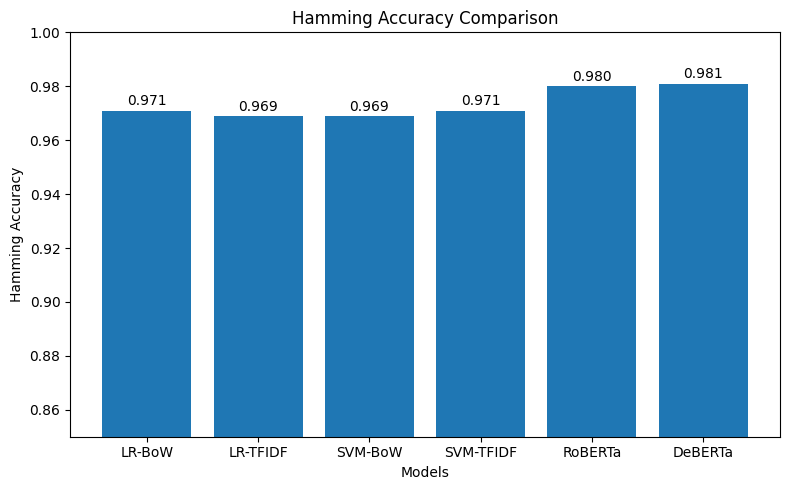

In [ ]:
import matplotlib.pyplot as plt

models = [
    "LR-BoW",
    "LR-TFIDF",
    "SVM-BoW",
    "SVM-TFIDF",
    "RoBERTa",
    "DeBERTa"
]

hamming_acc = [
    0.971,   # LR-BoW
    0.969,   # LR-TFIDF
    0.969,   # SVM-BoW
    0.971,   # SVM-TFIDF
    0.980,   # RoBERTa
    0.981   # DeBERTa
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, hamming_acc)

plt.title("Hamming Accuracy Comparison")
plt.ylabel("Hamming Accuracy")
plt.xlabel("Models")

plt.ylim(0.85, 1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.3f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

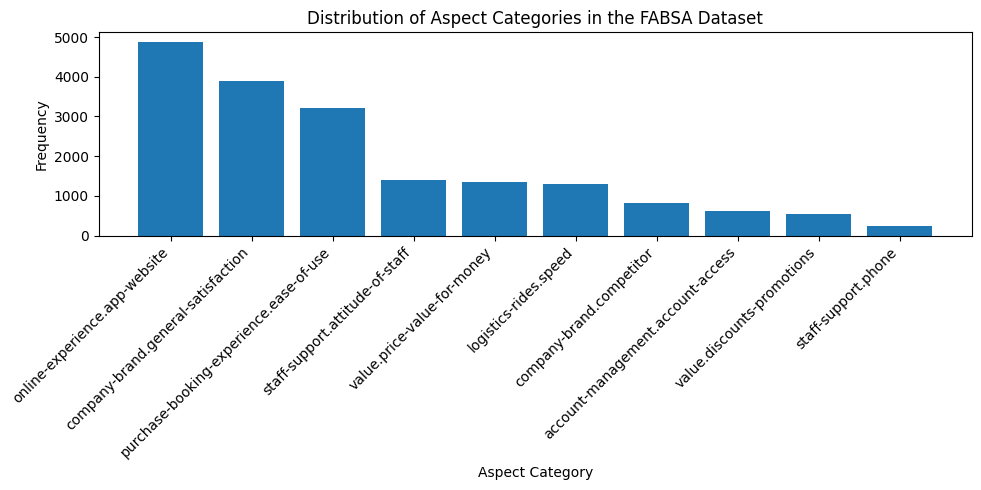

In [ ]:
import pandas as pd
import ast
from collections import Counter
import matplotlib.pyplot as plt

df = pd.read_csv("fabsa_dataset.csv")

aspect_counter = Counter()

for labels in df["labels"]:
    labels = ast.literal_eval(labels)

    for label in labels:
        aspect = ".".join(label.split(".")[:-1])
        aspect_counter[aspect] += 1

top_aspects = dict(aspect_counter.most_common(10))

plt.figure(figsize=(10,5))
plt.bar(top_aspects.keys(), top_aspects.values())

plt.title("Distribution of Aspect Categories in the FABSA Dataset")
plt.xlabel("Aspect Category")
plt.ylabel("Frequency")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Saving Best Model

In [ ]:
model.save_pretrained("deberta_absa_model")
tokenizer.save_pretrained("deberta_absa_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('deberta_absa_model/tokenizer_config.json',
 'deberta_absa_model/tokenizer.json')

In [ ]:
!zip -r deberta_absa_model.zip deberta_absa_model

  adding: deberta_absa_model/ (stored 0%)
  adding: deberta_absa_model/model.safetensors (deflated 7%)
  adding: deberta_absa_model/config.json (deflated 68%)
  adding: deberta_absa_model/tokenizer_config.json (deflated 48%)
  adding: deberta_absa_model/tokenizer.json (deflated 82%)
